In [1]:
# Step 1

import sys 
import numpy as np

sys.path.append('../')
sys.path.append('../printer')
sys.path.append('../lockinAmp')

from scanner import Scanner

In [ ]:
#For troubleshooting connection issues

import pyvisa as visa

rm = visa.ResourceManager('@py')
print(rm.list_resources())
potential_device = rm.open_resource("GPIB::8::INSTR", write_termination="\n", read_termination="\n")
print(potential_device)
potential_device.write("*IDN?")

In [2]:
######### kagome manual chirp scan

import sys 
import numpy as np
import os
import time
from tqdm import tqdm
import pickle

sys.path.append('../')
sys.path.append('../lockinAmp')


from srsamp import LockinAmp

lockin = LockinAmp()
lockin.initialize_amp()

Checking out device with ID: Stanford_Research_Systems,SR830,s/n81171,ver1.07 

Connecting to device with ID Stanford_Research_Systems,SR830,s/n81171,ver1.07 



In [6]:
freq_min = 1000
freq_max = 20000
freq_num = 951
outputAmp = 0.6
sg_delay = 0.15
relax = 0.05


freqs = np.linspace(freq_min, freq_max, freq_num)

data = []

for freq in tqdm(freqs):
    
    lockin.set_output(frequency = freq, amplitude = outputAmp)
    
    time.sleep(sg_delay)

    lockin.device.write("SNAP? 3,4\n") 
    amp, phase = [float(value) for value in lockin.device.read().split(',')] 
    
    data.append((freq, amp, phase))
    time.sleep(relax)

lockin.set_output(frequency = 1000, amplitude = 0.004) 

100%|██████████| 951/951 [03:59<00:00,  3.98it/s]


In [7]:
#filename = savefolder + "aluminumPlate.pkl"

currentCoord = [12, 12]
savefolder = '../../data/kagome-01.21.2022-corner/raw/gamma-K-2/'
filename = savefolder + "scppos_{}_{}.pkl".format(currentCoord[0], currentCoord[1])    
np.array(data).dump(filename)

In [2]:
# Step 2

scan = Scanner()

Checking out device with ID: Stanford_Research_Systems,SR830,s/n81171,ver1.07 

Connecting to device with ID Stanford_Research_Systems,SR830,s/n81171,ver1.07 

Trying to connect printer through USB port /dev/ttyACM1
Loaded position x = -6831.380000000076, y = 199.27162162144032, z = -58.5 from config file
Attempting to look for connections on: /dev/ttyACM1
Printer connected!


In [14]:
scan.p.move_coord(x=0, y=0, z=5)

In [ ]:
import time

time.sleep(0)
scan.amp.set_output(frequency = 14000, amplitude =4)

data = scan.amp.record(2)
scan.amp.set_output(frequency = 100, amplitude = 0.01)

ampdata = []
phasedata = []

for amp, phase in data:
    ampdata.append(amp)
    phasedata.append(phase)

ampdata = np.array(ampdata)
print(np.average(ampdata))

IndexError: list index out of range

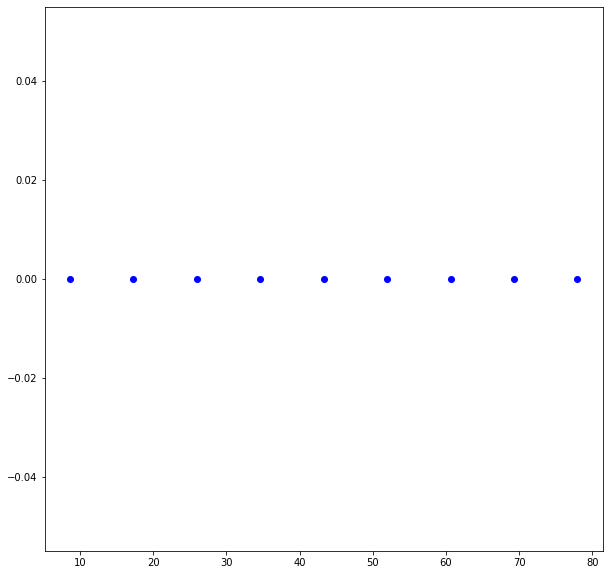

In [182]:
# Visualizing the scan sites

from scanner import kagome_lattice
from scanner import extkag_lattice
from scanner import sort_lattice_sites
import matplotlib.pyplot as plt
import operator
#lattice = scan.find_lattice_sites((30, 30), 10.0, kagome_lattice[0][0], 0.0, kagome_lattice)
lattice = sort_lattice_sites(scan.find_lattice_sites(area = (85, 3), 
                                            unit_cell = 10.0, 
                                            lattice_offset = kagome_lattice[1][0], 
                                            angle = 0.0, 
                                            lattice_type = kagome_lattice), cutoff = (kagome_lattice[0][1] / 2.0)**2)
#(kagome_lattice[0][1] / 2.0)**2
#print(lattice)
xdata = []
ydata = []
for x, y in lattice:
    xdata.append(x)
    ydata.append(y)

for point in lattice:
    point = tuple(map(operator.add, point, (1.0,1.0)))
    #print(point)

#print(lattice)
    
plt.figure(figsize=(10,10))
plt.plot(xdata,ydata,'bo')
#plt.plot(xdata[226:336], ydata[226:336], 'ro')
#plt.plot(list(np.zeros(5)), list(np.linspace(15, 15+30*4, 5)), 'ro')
ax = plt.gca()
ax.set_aspect("auto")
plt.savefig("../../data/figures/lattice_visualization")

print(xdata[40], ydata[40])
print(len(xdata))

In [ ]:
##### Extended kagome chirp scan

from scanner import extkag_lattice


scan.site_chirp_scan(area = (150, 150), min_freq = 6000, max_freq = 20000, 
                        sample_no = 60, lattice_offset = (-0.1830, -0.3170),
                        unit_cell = 20.0, amplitude = 4.0, g_delay = 0.5,                        
                        angle = 0.0, lattice_type = extkag_lattice, speed = 2000, title = "chirp_extkag_2000-16000Hz_0624", 
                        savepath = "../../data", note = '', relax = 0.0, gdz = 3.0)





In [46]:
##### Kagome chirp scan most recent version

import numpy as np
from scanner import kagome_lattice


currentCoord = (3*4.33, 0.0)
sample_no = 500
manual_delay = 35
gdz = 8.0
amplitude = 5
title = "chirp_kagome_2transducer_2-16kHz_0818"
descent_delay = 3.5

for i in range(25):
    
    if i%4 == 0:
        
        scan.site_chirp_scan(area = (160, 3), min_freq = 2000, max_freq = 16000, 
                        sample_no = sample_no, lattice_offset = kagome_lattice[0][0],
                        unit_cell = 10.0, amplitude = amplitude, g_delay = 0.5,                        
                        angle = 0.0, lattice_type = kagome_lattice, speed = 2000, title = title, 
                        savepath = "../../data", note = '', relax = 0.0, gdz = gdz, descent_delay = descent_delay,  manual_delay = manual_delay, sg_delay=0.02,
                        currentCoord = currentCoord)
        
        scan.p.move_coord(x=-3*4.33, y=7.5, z=0)
        currentCoord = tuple(np.array(currentCoord) + np.array([-3*4.33, 7.5]))
        
    elif i%4 == 1:
        scan.site_chirp_scan(area = (175, 3), min_freq = 2000, max_freq = 16000, 
                        sample_no = sample_no, lattice_offset = kagome_lattice[1][0],
                        unit_cell = 10.0, amplitude = amplitude, g_delay = 0.5,                        
                        angle = 0.0, lattice_type = kagome_lattice, speed = 2000, title = title, 
                        savepath = "../../data", note = '', relax = 0.0, gdz = gdz, descent_delay = descent_delay,  manual_delay = manual_delay, sg_delay=0.02,
                        currentCoord = currentCoord)
        
        scan.p.move_coord(x=4.33, y=7.5, z=0)
        currentCoord = tuple(np.array(currentCoord) + np.array([4.33, 7.5]))
    elif i%4 == 2:
        scan.site_chirp_scan(area = (160, 3), min_freq = 2000, max_freq = 16000, 
                        sample_no = sample_no, lattice_offset = kagome_lattice[0][0],
                        unit_cell = 10.0, amplitude = amplitude, g_delay = 0.5,                        
                        angle = 0.0, lattice_type = kagome_lattice, speed = 2000, title = title, 
                        savepath = "../../data", note = '', relax = 0.0, gdz = gdz, descent_delay = descent_delay,  manual_delay = manual_delay, sg_delay=0.02,
                        currentCoord = currentCoord)
        
        scan.p.move_coord(x=-4.33, y=7.5, z=0)
        currentCoord = tuple(np.array(currentCoord) + np.array([-4.33, 7.5]))
    
    elif i%4 == 3:
        scan.site_chirp_scan(area = (175, 3), min_freq = 2000, max_freq = 16000, 
                        sample_no = sample_no, lattice_offset = kagome_lattice[1][0],
                        unit_cell = 10.0, amplitude = amplitude, g_delay = 0.5,                        
                        angle = 0.0, lattice_type = kagome_lattice, speed = 2000, title = title, 
                        savepath = "../../data", note = '', relax = 0.0, gdz = gdz, descent_delay = descent_delay,  manual_delay = manual_delay, sg_delay=0.02,
                        currentCoord = currentCoord)
        
        scan.p.move_coord(x=3*4.33, y=7.5, z=0)
        currentCoord = tuple(np.array(currentCoord) + np.array([3*4.33, 7.5]))

Scanning via chirp!
[(17.32, 0.0), (34.64050807568877, 0.0), (51.961016151377535, 0.0), (69.28152422706631, 0.0), (86.60203230275508, 0.0), (103.92254037844384, 0.0), (121.24304845413263, 0.0), (138.5635565298214, 0.0), (155.88406460551016, 0.0)]


100%|██████████| 9/9 [16:10<00:00, 107.79s/it]


Total Scan Time: 1093.514509677887 s
Scanning via chirp!
[(8.66, 0.0), (17.320254037844386, 0.0), (25.980508075688768, 0.0), (34.64076211353316, 0.0), (43.30101615137754, 0.0), (51.96127018922192, 0.0), (60.62152422706632, 0.0), (69.2817782649107, 0.0), (77.94203230275508, 0.0), (86.60228634059948, 0.0), (95.26254037844384, 0.0), (103.92279441628824, 0.0), (112.58304845413264, 0.0), (121.243302491977, 0.0), (129.9035565298214, 0.0), (138.56381056766577, 0.0), (147.22406460551016, 0.0), (155.88431864335456, 0.0), (164.54457268119896, 0.0), (173.20482671904333, 0.0)]


100%|██████████| 20/20 [35:51<00:00, 107.57s/it]


Total Scan Time: 2276.555385351181 s
Scanning via chirp!
[(17.32, 0.0), (34.64050807568877, 0.0), (51.961016151377535, 0.0), (69.28152422706631, 0.0), (86.60203230275508, 0.0), (103.92254037844384, 0.0), (121.24304845413263, 0.0), (138.5635565298214, 0.0), (155.88406460551016, 0.0)]


...

Total Scan Time: 1093.7618894577026 s
Scanning via chirp!
[(8.66, 0.0), (17.320254037844386, 0.0), (25.980508075688768, 0.0), (34.64076211353316, 0.0), (43.30101615137754, 0.0), (51.96127018922192, 0.0), (60.62152422706632, 0.0), (69.2817782649107, 0.0), (77.94203230275508, 0.0), (86.60228634059948, 0.0), (95.26254037844384, 0.0), (103.92279441628824, 0.0), (112.58304845413264, 0.0), (121.243302491977, 0.0), (129.9035565298214, 0.0), (138.56381056766577, 0.0), (147.22406460551016, 0.0), (155.88431864335456, 0.0), (164.54457268119896, 0.0), (173.20482671904333, 0.0)]


100%|██████████| 20/20 [35:52<00:00, 107.61s/it]


Total Scan Time: 2277.466150045395 s
Scanning via chirp!
[(17.32, 0.0), (34.64050807568877, 0.0), (51.961016151377535, 0.0), (69.28152422706631, 0.0), (86.60203230275508, 0.0), (103.92254037844384, 0.0), (121.24304845413263, 0.0), (138.5635565298214, 0.0), (155.88406460551016, 0.0)]


100%|██████████| 9/9 [16:10<00:00, 107.80s/it]


Total Scan Time: 1093.728774547577 s


In [18]:
import pickle

with open('../../data/test/scppos_0.0_0.0.pkl', 'rb') as f:
    data = pickle.load(f)
    
print(data)

[[ 2.00000000e+03  6.10356000e-05  6.34380000e+01]
 [ 3.55555556e+03  3.66213000e-04  7.47480000e+01]
 [ 5.11111111e+03  9.15531000e-04  3.20040000e+01]
 [ 6.66666667e+03  4.94388000e-03 -6.67020000e+01]
 [ 8.22222222e+03  1.03761000e-03 -1.27260000e+01]
 [ 9.77777778e+03  3.23488000e-03  7.21200000e+01]
 [ 1.13333333e+04  5.06595000e-03  1.49418000e+02]
 [ 1.28888889e+04  1.03761000e-03  1.51824000e+02]
 [ 1.44444444e+04  1.03761000e-03  9.00000000e+01]
 [ 1.60000000e+04  2.44142000e-04  5.01960000e+01]]


In [5]:
##### Kagome chirp scan part 2

import numpy as np
from scanner import kagome_lattice


currentCoord = (4.33*3, 105.0)
sample_no = 500
manual_delay = 35

for i in range(25):
    
    if i%4 == 0:
        
        scan.site_chirp_scan(area = (160, 3), min_freq = 2000, max_freq = 16000, 
                        sample_no = sample_no, lattice_offset = kagome_lattice[0][0],
                        unit_cell = 10.0, amplitude = 4, g_delay = 0.5,                        
                        angle = 0.0, lattice_type = kagome_lattice, speed = 2000, title = "chirp_kagome_centralSource_2-16kHz_0802", 
                        savepath = "../../data", note = '', relax = 0.0, gdz = 4.0, descent_delay = 2,  manual_delay = manual_delay, sg_delay=0.02,
                        currentCoord = currentCoord)
        
        scan.p.move_coord(x=-4.33*3, y=7.5, z=0)
        currentCoord = tuple(np.array(currentCoord) + np.array([-4.33*3, 7.5]))
        
    elif i%4 == 1:
        scan.site_chirp_scan(area = (175, 3), min_freq = 2000, max_freq = 16000, 
                        sample_no = sample_no, lattice_offset = kagome_lattice[1][0],
                        unit_cell = 10.0, amplitude = 4, g_delay = 0.5,                        
                        angle = 0.0, lattice_type = kagome_lattice, speed = 2000, title = "chirp_kagome_centralSource_2-16kHz_0802", 
                        savepath = "../../data", note = '', relax = 0.0, gdz = 4.0, descent_delay = 2,  manual_delay = manual_delay, sg_delay=0.02,
                        currentCoord = currentCoord)
        
        scan.p.move_coord(x=4.33, y=7.5, z=0)
        currentCoord = tuple(np.array(currentCoord) + np.array([4.33, 7.5]))
    elif i%4 == 2:
        scan.site_chirp_scan(area = (160, 3), min_freq = 2000, max_freq = 16000, 
                        sample_no = sample_no, lattice_offset = kagome_lattice[0][0],
                        unit_cell = 10.0, amplitude = 4, g_delay = 0.5,                        
                        angle = 0.0, lattice_type = kagome_lattice, speed = 2000, title = "chirp_kagome_centralSource_2-16kHz_0802", 
                        savepath = "../../data", note = '', relax = 0.0, gdz = 4.0, descent_delay = 2,  manual_delay = manual_delay, sg_delay=0.02,
                        currentCoord = currentCoord)
        
        scan.p.move_coord(x=-4.33, y=7.5, z=0)
        currentCoord = tuple(np.array(currentCoord) + np.array([-4.33, 7.5]))
    
    elif i%4 == 3:
        scan.site_chirp_scan(area = (175, 3), min_freq = 2000, max_freq = 16000, 
                        sample_no = sample_no, lattice_offset = kagome_lattice[1][0],
                        unit_cell = 10.0, amplitude = 4, g_delay = 0.5,                        
                        angle = 0.0, lattice_type = kagome_lattice, speed = 2000, title = "chirp_kagome_centralSource_2-16kHz_0802", 
                        savepath = "../../data", note = '', relax = 0.0, gdz = 4.0, descent_delay = 2,  manual_delay = manual_delay, sg_delay=0.02,
                        currentCoord = currentCoord)
        
        scan.p.move_coord(x=3*4.33, y=7.5, z=0)
        currentCoord = tuple(np.array(currentCoord) + np.array([3*4.33, 7.5]))

ModuleNotFoundError: No module named 'scanner'

In [ ]:
#Continuous scan
frequency = 14000

scan.scan_continuous_lattice(200, 200, 201, frequency, scan_speed = 1500,
        delay = 0.5, amplitude = 4.0, savepath="../../data", title = "{}Hz_200*200_0622".format(frequency), note="")


In [36]:
#Measuring the frequency response 
from tqdm import tqdm
import matplotlib.pyplot as plt
import pickle
import time

freqmin = 2000
freqmax = 20000
freqnum = 650

record_time = 0.5

print("Time needed: " + str(record_time * freqnum / 60) + " minutes")

freqs = np.linspace(freqmin, freqmax, freqnum)
outputAmp = 3

freqResponse = []
phaseResponse = []

for i in tqdm(range(len(freqs))):
    scan.amp.set_output(frequency = freqs[i], amplitude = outputAmp)
    #time.sleep(0.1)
    data = scan.amp.record(record_time)
    #data = scan.amp.collect_data(data_type = 0)
    data = np.array(data)
    amp = data[:,0]
    phase = data[:,1]
    
    freqResponse.append(np.average(amp))
    phaseResponse.append(np.average(phase))

scan.amp.set_output(frequency = 1000, amplitude = 0.004)


with open('../../data/new_mic/oldmic_response.pkl', 'wb') as f:
    dataDump = [freqs, freqResponse, phaseResponse]
    pickle.dump(dataDump,f)

  0%|          | 0/650 [00:00<?, ?it/s]

Time needed: 5.416666666666667 minutes


100%|██████████| 650/650 [05:51<00:00,  1.85it/s]


In [35]:
scan.p.move_coord(x=0, y=0, z=-3)

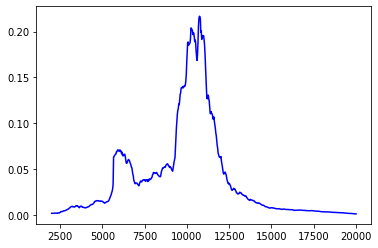

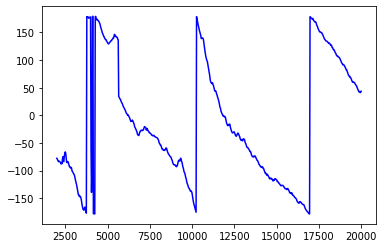

In [37]:
plt.plot(freqs, freqResponse, 'b-')

plt.figure()
plt.plot(freqs, phaseResponse, 'b-')
#plt.axis([0, 19000, 0, 1.2])


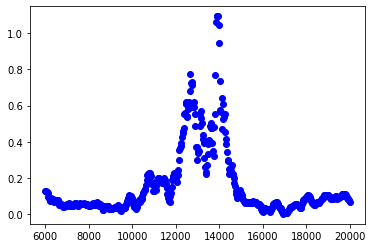

In [7]:
import matplotlib.pyplot as plt
import pickle

plt.plot(freqs, freqResponse, 'bo')

with open('../../data/new_mic/oldmic_response.pkl', 'rb') as f:
    data = pickle.load(f)